# Tyre Degradation Model & Monte Carlo Race Strategy Simulator
### Monza 2024 Race — Charles Leclerc

This notebook builds a data-driven tyre degradation model from real FastF1 race data, then uses it as the foundation for a Monte Carlo race strategy simulator.

**Methodology note:** Outlier laps are only removed when there is an independent, documented justification (e.g. a confirmed pit lap via `PitInTime`). A lap is never removed just because it looks statistically unusual — this avoids cherry-picking results.


In [1]:
import fastf1
import fastf1.plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Set up cache
os.makedirs("f1_cache", exist_ok=True)
fastf1.Cache.enable_cache("f1_cache")

# Load the Monza 2024 race session data 
session = fastf1.get_session(2024, "Monza", "R")
session.load()

print("Race data loaded successfully!")

core           INFO 	Loading data for Italian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['16', '81', '4', '55', '44', '1', '63', '11', '23', '20', '14', '43', '3', '31', '10', '77', '27', '24', '18', '22']


Race data loaded successfully!


In [2]:
# Get all laps for Leclerc during the race
leclerc_laps = session.laps.pick_drivers("LEC")

# Show which tyre compounds he used and how many laps per stint
stint_summary = leclerc_laps.groupby(["Stint", "Compound"])["LapNumber"].count()
print(stint_summary)

Stint  Compound
1.0    MEDIUM      15
2.0    HARD        38
Name: LapNumber, dtype: int64


## Part 1: Tyre Degradation Analysis

### Stint 2 (Hard Compound)


In [3]:
# Filter only Stint 2 (the long Hard-tyre stint)
stint2 = leclerc_laps[leclerc_laps["Stint"] == 2.0]

# remove laps affected by pit stops, safety cars, etc.
stint2 = stint2.pick_quicklaps()

# Convert LapTime from Timedelta to seconds
stint2 = stint2.copy()
stint2["LapTimeSeconds"] = stint2["LapTime"].dt.total_seconds()

print(f"Number of clean laps in stint: {len(stint2)}")
print(stint2[["LapNumber", "LapTimeSeconds", "TyreLife"]].head(10))

Number of clean laps in stint: 37
    LapNumber  LapTimeSeconds  TyreLife
16       17.0          84.270       2.0
17       18.0          83.875       3.0
18       19.0          84.203       4.0
19       20.0          83.826       5.0
20       21.0          83.880       6.0
21       22.0          83.768       7.0
22       23.0          83.864       8.0
23       24.0          83.640       9.0
24       25.0          83.590      10.0
25       26.0          83.321      11.0


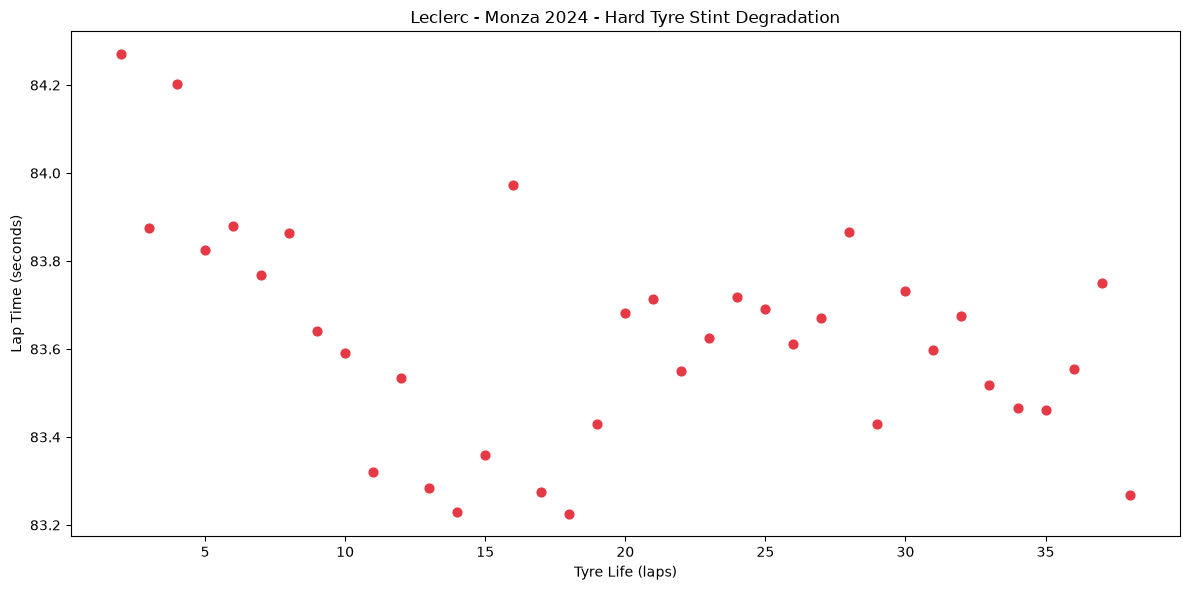

In [4]:
# Plot lap time vs tyre age to visualize degradation
fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(stint2["TyreLife"], stint2["LapTimeSeconds"], color="#e63946", s=40)

ax.set_xlabel("Tyre Life (laps)")
ax.set_ylabel("Lap Time (seconds)")
ax.set_title("Leclerc - Monza 2024 - Hard Tyre Stint Degradation")
plt.tight_layout()
plt.show()

In [5]:
# Sort by tyre life and display all laps with their lap times
stint2_sorted = stint2.sort_values("TyreLife")
print(stint2_sorted[["LapNumber", "TyreLife", "LapTimeSeconds", "TrackStatus"]].to_string(index=False))

 LapNumber  TyreLife  LapTimeSeconds TrackStatus
      17.0       2.0          84.270           1
      18.0       3.0          83.875           1
      19.0       4.0          84.203           1
      20.0       5.0          83.826           1
      21.0       6.0          83.880           1
      22.0       7.0          83.768           1
      23.0       8.0          83.864           1
      24.0       9.0          83.640           1
      25.0      10.0          83.590           1
      26.0      11.0          83.321           1
      27.0      12.0          83.534           1
      28.0      13.0          83.284           1
      29.0      14.0          83.229           1
      30.0      15.0          83.359           1
      31.0      16.0          83.972           1
      32.0      17.0          83.274           1
      33.0      18.0          83.226           1
      34.0      19.0          83.430           1
      35.0      20.0          83.681           1
      36.0      21.0

In [6]:
# Find laps with unusually high lap times (potential outliers)
mean_time = stint2["LapTimeSeconds"].mean()
std_time = stint2["LapTimeSeconds"].std()

print(f"Average lap time: {mean_time:.3f}s")
print(f"Standard deviation: {std_time:.3f}s")

# Show laps that are more than 1.5 standard deviations slower than average
outliers = stint2[stint2["LapTimeSeconds"] > mean_time + 1.5 * std_time]
print("\nPotential outlier laps:")
print(outliers[["LapNumber", "TyreLife", "LapTimeSeconds", "TrackStatus"]])

Average lap time: 83.625s
Standard deviation: 0.249s

Potential outlier laps:
    LapNumber  TyreLife  LapTimeSeconds TrackStatus
16       17.0       2.0          84.270           1
18       19.0       4.0          84.203           1


In [7]:
# Remove the tyre warm-up phase (first 4 laps) to isolate pure degradation behavior
stint2_clean = stint2[stint2["TyreLife"] > 4].copy()

print(f"Laps remaining after removing warm-up phase: {len(stint2_clean)}")

Laps remaining after removing warm-up phase: 34


In [8]:
from sklearn.linear_model import LinearRegression

X = stint2_clean[["TyreLife"]].values
y = stint2_clean["LapTimeSeconds"].values

model = LinearRegression()
model.fit(X, y)

slope = model.coef_[0]
intercept = model.intercept_

print(f"Slope (degradation rate): {slope:.4f} seconds per lap")
print(f"Intercept: {intercept:.3f} seconds")

Slope (degradation rate): -0.0024 seconds per lap
Intercept: 83.633 seconds


R² (coefficient of determination): 0.0136
This means TyreLife explains 1.4% of the variance in lap times


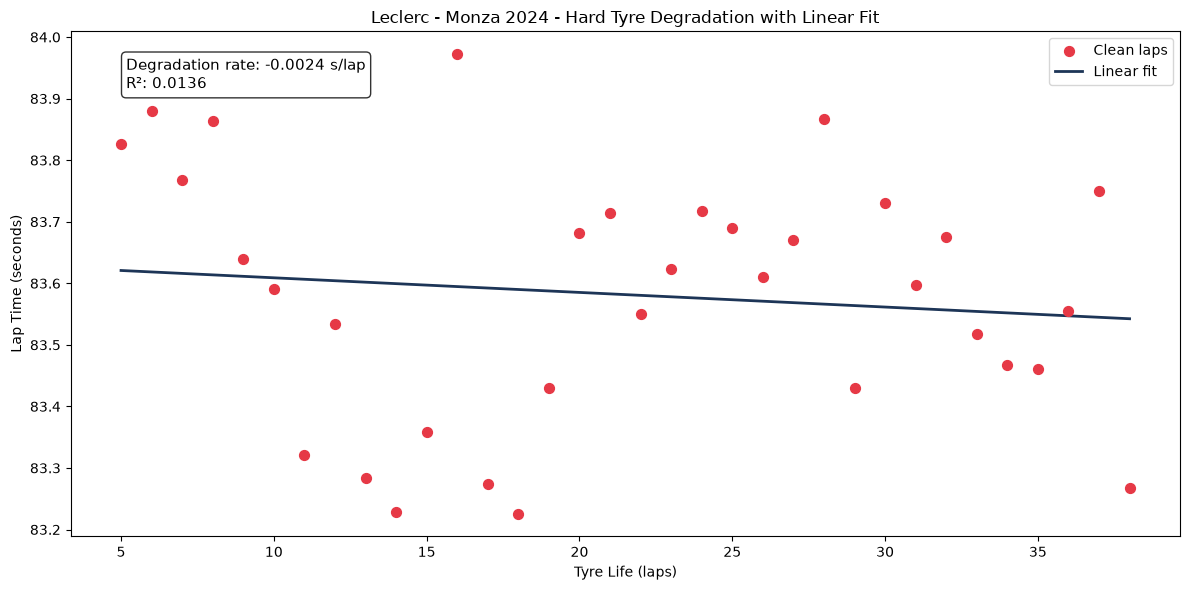

In [9]:
# Generate predictions across the full tyre life range for a smooth regression line
tyre_life_range = np.linspace(stint2_clean["TyreLife"].min(), stint2_clean["TyreLife"].max(), 100).reshape(-1, 1)
predicted_laptimes = model.predict(tyre_life_range)

# Calculate R² to quantify how much variance TyreLife actually explains
r_squared = model.score(X, y)
print(f"R² (coefficient of determination): {r_squared:.4f}")
print(f"This means TyreLife explains {r_squared*100:.1f}% of the variance in lap times")

fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(stint2_clean["TyreLife"], stint2_clean["LapTimeSeconds"], 
           color="#e63946", s=50, zorder=3, label="Clean laps")

ax.plot(tyre_life_range, predicted_laptimes, 
        color="#1d3557", linewidth=2, zorder=2, label="Linear fit")

# Annotate the slope directly on the plot
ax.text(0.05, 0.95, f"Degradation rate: {slope:.4f} s/lap\nR²: {r_squared:.4f}", 
        transform=ax.transAxes, fontsize=11, verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

ax.set_xlabel("Tyre Life (laps)")
ax.set_ylabel("Lap Time (seconds)")
ax.set_title("Leclerc - Monza 2024 - Hard Tyre Degradation with Linear Fit")
ax.legend()
plt.tight_layout()
plt.show()

### Stint 1 (Medium Compound)


In [10]:
# Filter Stint 1 (Medium tyre) and apply the same cleaning steps as Stint 2
stint1 = leclerc_laps[leclerc_laps["Stint"] == 1.0]
stint1 = stint1.pick_quicklaps()
stint1 = stint1.copy()
stint1["LapTimeSeconds"] = stint1["LapTime"].dt.total_seconds()

print(f"Number of clean laps in Stint 1: {len(stint1)}")

# Remove the tyre warm-up phase (first 4 laps), same threshold as Stint 2 for consistency
stint1_clean = stint1[stint1["TyreLife"] > 4].copy()
print(f"Laps remaining after removing warm-up phase: {len(stint1_clean)}")

Number of clean laps in Stint 1: 15
Laps remaining after removing warm-up phase: 11


In [11]:
# Check for outlier laps in Stint 1 using the same method as Stint 2
mean_time_s1 = stint1_clean["LapTimeSeconds"].mean()
std_time_s1 = stint1_clean["LapTimeSeconds"].std()
print(f"Stint 1 - Average lap time: {mean_time_s1:.3f}s")
print(f"Stint 1 - Standard deviation: {std_time_s1:.3f}s")

outliers_s1 = stint1_clean[stint1_clean["LapTimeSeconds"] > mean_time_s1 + 1.5 * std_time_s1]
print("\nPotential outlier laps in Stint 1:")
print(outliers_s1[["LapNumber", "TyreLife", "LapTimeSeconds", "TrackStatus"]])

Stint 1 - Average lap time: 85.287s
Stint 1 - Standard deviation: 1.680s

Potential outlier laps in Stint 1:
    LapNumber  TyreLife  LapTimeSeconds TrackStatus
14       15.0      15.0          90.192           1


In [12]:
# Check if Lap 15 was a pit-in lap (which would explain the abnormally slow time)
lap15_check = leclerc_laps[leclerc_laps["LapNumber"] == 15][["LapNumber", "PitInTime", "PitOutTime", "TyreLife", "Stint"]]
print(lap15_check) 

    LapNumber              PitInTime PitOutTime  TyreLife  Stint
14       15.0 0 days 01:17:08.772000        NaT      15.0    1.0


In [13]:
# Remove Lap 15 - confirmed to be the pit-in lap (not representative of pure tyre degradation)
stint1_clean = stint1_clean[stint1_clean["LapNumber"] != 15]
print(f"Laps remaining after removing pit-in lap: {len(stint1_clean)}")

Laps remaining after removing pit-in lap: 10


In [14]:
# Fit linear regression on Stint 1 (Medium tyre)
X_s1 = stint1_clean[["TyreLife"]].values
y_s1 = stint1_clean["LapTimeSeconds"].values

model_s1 = LinearRegression()
model_s1.fit(X_s1, y_s1)

slope_s1 = model_s1.coef_[0]
intercept_s1 = model_s1.intercept_
r_squared_s1 = model_s1.score(X_s1, y_s1)

print(f"Stint 1 (Medium) - Slope: {slope_s1:.4f} seconds per lap")
print(f"Stint 1 (Medium) - Intercept: {intercept_s1:.3f} seconds")
print(f"Stint 1 (Medium) - R²: {r_squared_s1:.4f}")

Stint 1 (Medium) - Slope: 0.1115 seconds per lap
Stint 1 (Medium) - Intercept: 83.737 seconds
Stint 1 (Medium) - R²: 0.5801


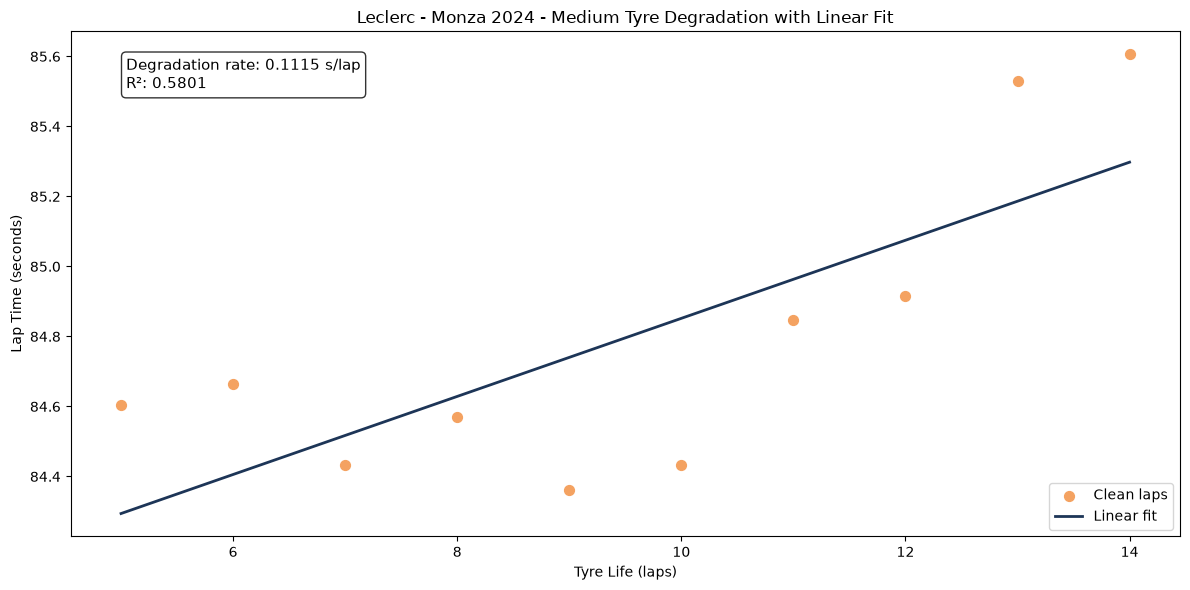

In [15]:
# Generate predictions for a smooth regression line
tyre_life_range_s1 = np.linspace(stint1_clean["TyreLife"].min(), stint1_clean["TyreLife"].max(), 100).reshape(-1, 1)
predicted_laptimes_s1 = model_s1.predict(tyre_life_range_s1)

# Plot Stint 1 (Medium) degradation
fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(stint1_clean["TyreLife"], stint1_clean["LapTimeSeconds"], 
           color="#f4a261", s=50, zorder=3, label="Clean laps")

ax.plot(tyre_life_range_s1, predicted_laptimes_s1, 
        color="#1d3557", linewidth=2, zorder=2, label="Linear fit")

ax.text(0.05, 0.95, f"Degradation rate: {slope_s1:.4f} s/lap\nR²: {r_squared_s1:.4f}", 
        transform=ax.transAxes, fontsize=11, verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

ax.set_xlabel("Tyre Life (laps)")
ax.set_ylabel("Lap Time (seconds)")
ax.set_title("Leclerc - Monza 2024 - Medium Tyre Degradation with Linear Fit")
ax.legend()
plt.tight_layout()
plt.show() 

### Compound Comparison

Side-by-side view of both compounds on a shared y-axis, to compare degradation slope and signal strength directly.


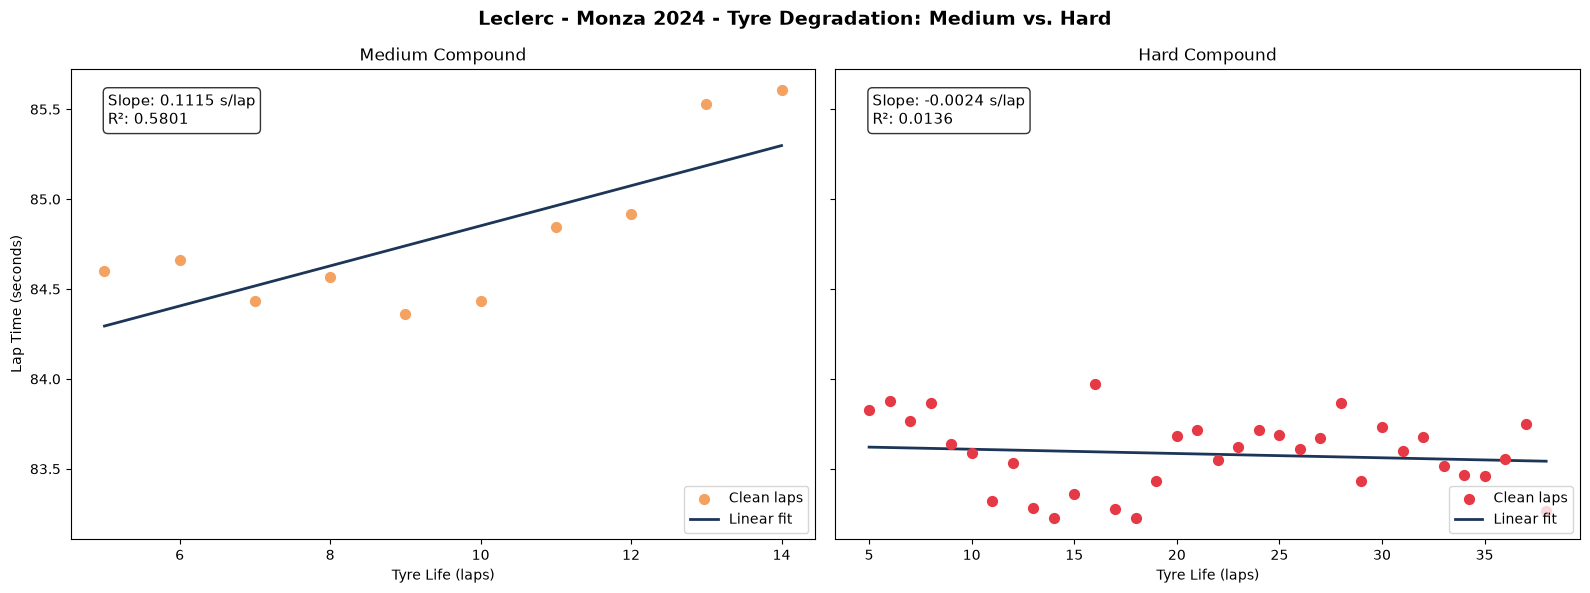

In [16]:
# Create a side-by-side comparison of both compounds' degradation behavior
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# --- Left subplot: Medium tyre (Stint 1) ---
axes[0].scatter(stint1_clean["TyreLife"], stint1_clean["LapTimeSeconds"], 
                 color="#f4a261", s=50, zorder=3, label="Clean laps")
axes[0].plot(tyre_life_range_s1, predicted_laptimes_s1, 
              color="#1d3557", linewidth=2, zorder=2, label="Linear fit")
axes[0].text(0.05, 0.95, f"Slope: {slope_s1:.4f} s/lap\nR²: {r_squared_s1:.4f}", 
              transform=axes[0].transAxes, fontsize=11, verticalalignment="top",
              bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
axes[0].set_xlabel("Tyre Life (laps)")
axes[0].set_ylabel("Lap Time (seconds)")
axes[0].set_title("Medium Compound")
axes[0].legend(loc="lower right")

# --- Right subplot: Hard tyre (Stint 2) ---
axes[1].scatter(stint2_clean["TyreLife"], stint2_clean["LapTimeSeconds"], 
                 color="#e63946", s=50, zorder=3, label="Clean laps")
axes[1].plot(tyre_life_range, predicted_laptimes, 
              color="#1d3557", linewidth=2, zorder=2, label="Linear fit")
axes[1].text(0.05, 0.95, f"Slope: {slope:.4f} s/lap\nR²: {r_squared:.4f}", 
              transform=axes[1].transAxes, fontsize=11, verticalalignment="top",
              bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
axes[1].set_xlabel("Tyre Life (laps)")
axes[1].set_title("Hard Compound")
axes[1].legend(loc="lower right")

fig.suptitle("Leclerc - Monza 2024 - Tyre Degradation: Medium vs. Hard", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show() 

## Part 2: Monte Carlo Race Strategy Simulator

### Step 1: Estimating the Fuel-Burn Effect from Real Race Data

Over a race, lap times get faster as fuel burns off, independent of tyre wear. Before modelling degradation for the simulator, we isolate this fuel-burn effect so it isn't mistaken for (or hidden inside) the tyre degradation signal.


In [17]:
# Prepare the full race dataset (both stints combined) for fuel-burn estimation
race_laps = leclerc_laps.pick_quicklaps().copy()
race_laps["LapTimeSeconds"] = race_laps["LapTime"].dt.total_seconds()

# Remove the same warm-up phase per stint (TyreLife > 4), consistent with our stint-level analysis
race_laps_clean = race_laps[race_laps["TyreLife"] > 4].copy()

# Remove the confirmed pit-in lap (Lap 15), same justification as before
race_laps_clean = race_laps_clean[race_laps_clean["LapNumber"] != 15]

print(f"Total clean laps across full race: {len(race_laps_clean)}")
print(race_laps_clean[["LapNumber", "Stint", "TyreLife", "LapTimeSeconds"]].to_string(index=False)) 

Total clean laps across full race: 44
 LapNumber  Stint  TyreLife  LapTimeSeconds
       5.0    1.0       5.0          84.603
       6.0    1.0       6.0          84.663
       7.0    1.0       7.0          84.434
       8.0    1.0       8.0          84.569
       9.0    1.0       9.0          84.362
      10.0    1.0      10.0          84.432
      11.0    1.0      11.0          84.846
      12.0    1.0      12.0          84.916
      13.0    1.0      13.0          85.529
      14.0    1.0      14.0          85.606
      20.0    2.0       5.0          83.826
      21.0    2.0       6.0          83.880
      22.0    2.0       7.0          83.768
      23.0    2.0       8.0          83.864
      24.0    2.0       9.0          83.640
      25.0    2.0      10.0          83.590
      26.0    2.0      11.0          83.321
      27.0    2.0      12.0          83.534
      28.0    2.0      13.0          83.284
      29.0    2.0      14.0          83.229
      30.0    2.0      15.0          8

In [18]:
# Add a binary compound indicator (0 = Medium, 1 = Hard) so the model can separate 
# the fuel-burn effect (LapNumber) from the baseline compound speed difference
race_laps_clean["IsHard"] = (race_laps_clean["Compound"] == "HARD").astype(int)

print(race_laps_clean[["LapNumber", "Compound", "IsHard", "TyreLife", "LapTimeSeconds"]].head(15))

    LapNumber Compound  IsHard  TyreLife  LapTimeSeconds
4         5.0   MEDIUM       0       5.0          84.603
5         6.0   MEDIUM       0       6.0          84.663
6         7.0   MEDIUM       0       7.0          84.434
7         8.0   MEDIUM       0       8.0          84.569
8         9.0   MEDIUM       0       9.0          84.362
9        10.0   MEDIUM       0      10.0          84.432
10       11.0   MEDIUM       0      11.0          84.846
11       12.0   MEDIUM       0      12.0          84.916
12       13.0   MEDIUM       0      13.0          85.529
13       14.0   MEDIUM       0      14.0          85.606
19       20.0     HARD       1       5.0          83.826
20       21.0     HARD       1       6.0          83.880
21       22.0     HARD       1       7.0          83.768
22       23.0     HARD       1       8.0          83.864
23       24.0     HARD       1       9.0          83.640


In [19]:
from sklearn.linear_model import LinearRegression

# Prepare the feature matrix with three inputs: LapNumber (fuel effect), 
# TyreLife (degradation), and IsHard (compound baseline difference)
X_fuel = race_laps_clean[["LapNumber", "TyreLife", "IsHard"]].values
y_fuel = race_laps_clean["LapTimeSeconds"].values

# Fit the multi-feature regression model
model_fuel = LinearRegression()
model_fuel.fit(X_fuel, y_fuel)

# Extract coefficients - order matches the column order in X_fuel
fuel_coef = model_fuel.coef_[0]      # effect of LapNumber (fuel burn)
tyre_coef = model_fuel.coef_[1]      # effect of TyreLife (degradation, now isolated from fuel)
compound_coef = model_fuel.coef_[2]  # effect of IsHard (baseline speed difference)
intercept_fuel = model_fuel.intercept_

r_squared_fuel = model_fuel.score(X_fuel, y_fuel)

print(f"Fuel-burn effect (per lap number): {fuel_coef:.4f} seconds/lap")
print(f"Tyre degradation effect (per tyre life unit): {tyre_coef:.4f} seconds/lap")
print(f"Compound baseline difference (Hard vs Medium): {compound_coef:.4f} seconds")
print(f"Intercept: {intercept_fuel:.3f} seconds")
print(f"R²: {r_squared_fuel:.4f}")

Fuel-burn effect (per lap number): -0.0806 seconds/lap
Tyre degradation effect (per tyre life unit): 0.0810 seconds/lap
Compound baseline difference (Hard vs Medium): -0.0108 seconds
Intercept: 84.792 seconds
R²: 0.7846


In [20]:
# Check correlation between LapNumber and IsHard to quantify the multicollinearity concern
correlation = race_laps_clean[["LapNumber", "TyreLife", "IsHard"]].corr()
print(correlation) 

           LapNumber  TyreLife    IsHard
LapNumber   1.000000  0.924522  0.791664
TyreLife    0.924522  1.000000  0.499058
IsHard      0.791664  0.499058  1.000000


### Step 1b: Isolating the Fuel-Burn Effect (Multi-Driver Approach)

The single-driver model above revealed severe multicollinearity between 
LapNumber and TyreLife (r=0.925), since Leclerc only pitted once. To break 
this collinearity and isolate a reliable fuel-burn coefficient, we extend 
the dataset to include multiple drivers with different pit stop timings.

In [21]:
# Get all laps from all drivers in the race (not just Leclerc)
all_laps = session.laps.pick_quicklaps().copy()
all_laps["LapTimeSeconds"] = all_laps["LapTime"].dt.total_seconds()

# Apply the same warm-up filter as before (per stint, works automatically 
# across all drivers since TyreLife resets at each pit stop)
all_laps_clean = all_laps[all_laps["TyreLife"] > 4].copy()

# Remove any lap that is a confirmed pit-in lap (same justification as Lap 15 
# for Leclerc), now applied across the whole grid using PitInTime directly
all_laps_clean = all_laps_clean[all_laps_clean["PitInTime"].isna()]

print(f"Total clean laps across all drivers: {len(all_laps_clean)}")
print(f"Number of unique drivers: {all_laps_clean['Driver'].nunique()}")

Total clean laps across all drivers: 774
Number of unique drivers: 20


In [22]:
# Check which compounds appear in the full-grid dataset
compound_summary = all_laps_clean.groupby("Compound")["LapNumber"].count()
print(compound_summary)

Compound
HARD      591
MEDIUM    183
Name: LapNumber, dtype: int64


In [23]:
# Add the same binary compound indicator as before
all_laps_clean["IsHard"] = (all_laps_clean["Compound"] == "HARD").astype(int)

# Fit the multi-feature regression model on the full grid
X_fuel_all = all_laps_clean[["LapNumber", "TyreLife", "IsHard"]].values
y_fuel_all = all_laps_clean["LapTimeSeconds"].values

model_fuel_all = LinearRegression()
model_fuel_all.fit(X_fuel_all, y_fuel_all)

fuel_coef_all = model_fuel_all.coef_[0]
tyre_coef_all = model_fuel_all.coef_[1]
compound_coef_all = model_fuel_all.coef_[2]
intercept_fuel_all = model_fuel_all.intercept_

r_squared_fuel_all = model_fuel_all.score(X_fuel_all, y_fuel_all)

print(f"Fuel-burn effect (per lap number): {fuel_coef_all:.4f} seconds/lap")
print(f"Tyre degradation effect (per tyre life unit): {tyre_coef_all:.4f} seconds/lap")
print(f"Compound baseline difference (Hard vs Medium): {compound_coef_all:.4f} seconds")
print(f"Intercept: {intercept_fuel_all:.3f} seconds")
print(f"R²: {r_squared_fuel_all:.4f}")

Fuel-burn effect (per lap number): -0.0620 seconds/lap
Tyre degradation effect (per tyre life unit): 0.0643 seconds/lap
Compound baseline difference (Hard vs Medium): -0.3231 seconds
Intercept: 85.786 seconds
R²: 0.4714


In [24]:
# Verify that multicollinearity has actually been reduced with the multi-driver dataset
correlation_all = all_laps_clean[["LapNumber", "TyreLife", "IsHard"]].corr()
print(correlation_all)

           LapNumber  TyreLife    IsHard
LapNumber   1.000000  0.538771  0.277066
TyreLife    0.538771  1.000000  0.323000
IsHard      0.277066  0.323000  1.000000


## Step 2: Modeling Lap Time Noise

The simulator needs a random component so simulated lap times scatter realistically around the model prediction, instead of falling exactly on the regression line. This scatter is estimated from the **residuals** of the multi-driver model (actual lap time minus predicted lap time) - i.e. the variation left over once fuel-burn, degradation and compound are already accounted for.

In [25]:
# Calculate residuals: the difference between actual lap times and what 
# the fuel+degradation+compound model predicted for each lap
predicted_all = model_fuel_all.predict(X_fuel_all)
residuals_all = y_fuel_all - predicted_all

print(f"Mean residual: {residuals_all.mean():.4f}s (should be ~0)")
print(f"Residual standard deviation: {residuals_all.std():.4f}s")

Mean residual: -0.0000s (should be ~0)
Residual standard deviation: 0.8302s


In [26]:
# Check whether residual variance differs meaningfully between compounds
residuals_df = all_laps_clean.copy()
residuals_df["Residual"] = residuals_all

residual_std_by_compound = residuals_df.groupby("Compound")["Residual"].std()
print(residual_std_by_compound)

Compound
HARD      0.815128
MEDIUM    0.881772
Name: Residual, dtype: float64


**Result:** Hard (σ = 0.815s) and Medium (σ = 0.882s) show a moderate difference, consistent with the stronger non-linear degradation behaviour observed for Medium earlier. Compound-specific noise values are used in the simulator rather than a single global value, for consistency with how the other parameters (degradation, fuel-burn interaction) were also estimated per compound.

## Step 3: Pit Stop Time Loss

`PitInTime` and `PitOutTime` mark the moments a driver crosses the pit entry and exit lines. Their difference is the full time spent in the pit lane (entry, tyre change, exit) - the real cost of a pit stop that the simulator needs to charge against any strategy that includes one.

In [27]:
# Diagnose: check how PitInTime and PitOutTime are actually distributed across rows
sample_driver = session.laps.pick_drivers("LEC")
print(sample_driver[["LapNumber", "PitInTime", "PitOutTime"]].dropna(how="all", subset=["PitInTime", "PitOutTime"]))

    LapNumber              PitInTime             PitOutTime
14       15.0 0 days 01:17:08.772000                    NaT
15       16.0                    NaT 0 days 01:17:33.191000


`PitInTime` and `PitOutTime` are split across two separate rows (the in-lap and the following out-lap), not stored together on one row. The two need to be aligned per driver before a pit duration can be calculated.

In [28]:
# For each driver, sort by lap number and pair each PitInTime with the PitOutTime 
# of the immediately following lap (since FastF1 splits them across two rows)
laps_sorted = session.laps.sort_values(["Driver", "LapNumber"]).copy()

# Shift PitOutTime up by one row *within each driver* to align it with the PitInTime row
laps_sorted["NextPitOutTime"] = laps_sorted.groupby("Driver")["PitOutTime"].shift(-1)

# Now filter to rows where PitInTime is set - these are confirmed pit-in laps
pit_laps = laps_sorted[laps_sorted["PitInTime"].notna()].copy()

# Calculate pit duration using the aligned PitOutTime
pit_laps["PitDuration"] = (pit_laps["NextPitOutTime"] - pit_laps["PitInTime"]).dt.total_seconds()

print(f"Number of completed pit stops detected: {pit_laps['PitDuration'].notna().sum()}")
print(pit_laps["PitDuration"].describe())

Number of completed pit stops detected: 30
count    30.000000
mean     26.164467
std       3.709682
min      23.763000
25%      24.304000
50%      24.783000
75%      25.559750
max      38.845000
Name: PitDuration, dtype: float64


In [29]:
# Identify which driver/lap the slowest pit stop belongs to, to check for an independent cause
slowest_stop = pit_laps.loc[pit_laps["PitDuration"].idxmax()]
print(slowest_stop[["Driver", "LapNumber", "PitDuration", "TrackStatus"]])

Driver            HUL
LapNumber         5.0
PitDuration    38.845
TrackStatus         1
dtype: object


**Result:** The slowest stop (HUL, Lap 5, 38.85s) shows `TrackStatus = 1` (green flag), so there is no independently documented cause (Safety Car, yellow flag) to justify removing it - and the very early lap number (5, well before typical strategy windows) suggests an unplanned event such as car damage, which `TrackStatus` would not capture either way. Consistent with the project's rule of only removing laps with independent justification, the value is kept. To stay robust against this single outlier, the **median** rather than the mean is used as the simulator's pit-stop time-loss value.

In [30]:
# Use the median pit duration as the simulator's baseline pit-stop time loss,
# since it is robust to the single unexplained outlier (HUL, Lap 5)
pit_stop_time_loss = pit_laps["PitDuration"].median()
print(f"Baseline pit-stop time loss for the simulator: {pit_stop_time_loss:.3f} seconds")

Baseline pit-stop time loss for the simulator: 24.783 seconds
